# Checkpoint 01 — 2º semestre
## Modelagem Linear Para Aprendizado de Máquina

### Avaliação: modelos de classificação

**Integrantes do grupo:**
| Nome | RM |
|---|---|
| *(Gustavos Henrique)* | *(569921)* |
| *(Ricardo do Santos)* | *(569600)* |
| *(Gabriel Vilas)* | *(571603)* |
| *(Mathues ferreira)* | *(569638)* |
| *(Vinicius Molena)* | *(571270)* |

**Turma:** *(preencher)*
**Data:** *(preencher)*
**Tema escolhido no Exercício 3:** Economia — *Bank Marketing* (UCI), previsão de contratação de depósito a prazo (`y`).

---

Esta avaliação acompanha um fluxo completo de classificação:

1. carregar dados de um arquivo CSV;
2. compreender o problema e a variável-alvo;
3. realizar uma análise exploratória inicial;
4. aplicar um pré-processamento básico;
5. separar dados de treino e teste;
6. treinar modelos com algoritmos do `scikit-learn`;
7. avaliar e comparar os resultados;
8. interpretar as limitações do modelo.

O trabalho possui **duas partes obrigatórias**:

- **Implementação:** entrega deste notebook preenchido, executado e com os resultados visíveis.
- **Apresentação:** demonstração, pelo grupo, da implementação escolhida no Exercício 3.

> O notebook deve registrar as decisões do grupo. Exibir somente a métrica final não demonstra o processo de modelagem.

## Regras gerais

- O trabalho deve ser realizado em grupo.
- Todos os integrantes devem compreender o código e participar da apresentação.
- O Exercício 1 é um exemplo resolvido e serve como referência.
- O Exercício 2 deve ser preenchido pelo grupo nas células indicadas.
- O Exercício 3 é o desafio principal e deve ser desenvolvido do início ao fim.
- Use `random_state=42` sempre que o algoritmo oferecer esse parâmetro.
- Não use a base de teste para ajustar o pré-processamento ou escolher o modelo.
- Toda métrica apresentada deve ser acompanhada de uma interpretação em Markdown.
- Bibliotecas adicionais podem ser utilizadas, mas os modelos devem pertencer ao `scikit-learn`.

### Evidências mínimas esperadas

- identificação da variável-alvo e das variáveis preditoras;
- dimensões, tipos de dados, valores ausentes, duplicidades e distribuição das classes;
- justificativa das etapas de pré-processamento;
- divisão entre dados de treino e teste;
- treinamento de um modelo de classificação;
- acurácia e matriz de confusão;
- conclusão técnica e limitações.

## Preparação do ambiente

Além das bibliotecas do enunciado, importamos `ColumnTransformer`, `OneHotEncoder` e `SimpleImputer`, que serão
necessários nos Exercícios 2 e 3 (bases com variáveis categóricas e valores ausentes), e `DummyClassifier`,
usado como linha de base para interpretar a acurácia em bases desbalanceadas.

In [53]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
PASTA_DADOS = "dados"
os.makedirs(PASTA_DADOS, exist_ok=True)

print("Ambiente preparado.")
print("pandas:", pd.__version__, "| numpy:", np.__version__)
import sklearn
print("scikit-learn:", sklearn.__version__)

Ambiente preparado.
pandas: 2.2.3 | numpy: 2.1.3
scikit-learn: 1.6.1


# Exercício 1 — Saúde: classificação de tumores
## Exemplo totalmente resolvido

Neste exemplo será utilizada a base **Breast Cancer Wisconsin (Diagnostic)**, distribuída com o `scikit-learn`. Cada registro reúne características calculadas a partir de imagens digitalizadas de massas mamárias.

A variável-alvo original possui duas classes:

- `0`: tumor maligno;
- `1`: tumor benigno.

Para tornar a classe de maior interesse clínico igual a `1`, criaremos a variável `maligno`:

- `1`: maligno;
- `0`: benigno.

O conjunto será primeiro salvo como `CSV` e depois carregado com `pandas`, reproduzindo o fluxo exigido na avaliação.

### 1.1 Criação e carga do arquivo CSV

In [54]:
from sklearn.datasets import load_breast_cancer

dados_sklearn = load_breast_cancer(as_frame=True)
df_original = dados_sklearn.frame.copy()

# Converte a classe de interesse (maligno) para 1.
df_original["maligno"] = (df_original["target"] == 0).astype(int)
df_original = df_original.drop(columns="target")

arquivo_csv = os.path.join(PASTA_DADOS, "dados_saude_tumores.csv")
df_original.to_csv(arquivo_csv, index=False)

# A análise começa efetivamente pela leitura de um arquivo CSV.
df = pd.read_csv(arquivo_csv)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 1.2 Inspeção inicial

Antes de construir gráficos ou treinar modelos, verificamos o tamanho da base, os tipos de dados e uma amostra dos registros. Isso ajuda a detectar problemas de leitura, colunas inesperadas e tipos incompatíveis.

In [55]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
display(df.head())
df.info()

Linhas: 569
Colunas: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### 1.3 Qualidade dos dados

Valores ausentes podem impedir o treinamento de alguns modelos. Registros duplicados podem dar peso indevido a determinadas observações. As duas verificações devem ocorrer antes da separação entre variáveis preditoras e alvo.

In [56]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes,
    "ausentes": df.isna().sum(),
    "percentual_ausentes": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

display(qualidade)
print("Registros duplicados:", df.duplicated().sum())

,tipo,ausentes,percentual_ausentes,valores_unicos
mean radius,float64,0,0.0,456
mean texture,float64,0,0.0,479
mean perimeter,float64,0,0.0,522
mean area,float64,0,0.0,539
mean smoothness,float64,0,0.0,474
mean compactness,float64,0,0.0,537
mean concavity,float64,0,0.0,537
mean concave points,float64,0,0.0,542
mean symmetry,float64,0,0.0,432
mean fractal dimension,float64,0,0.0,499


Registros duplicados: 0


### 1.4 Estatísticas descritivas e distribuição da classe

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,quantidade,percentual
maligno,,
0,357,62.74
1,212,37.26


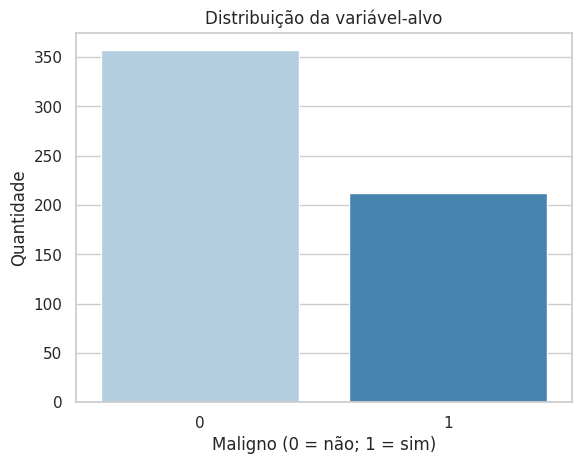

In [57]:
display(df.describe().T)

contagem_classes = df["maligno"].value_counts().sort_index()
percentual_classes = df["maligno"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "quantidade": contagem_classes,
    "percentual": percentual_classes.round(2)
}))

ax = sns.countplot(data=df, x="maligno", palette="Blues")
ax.set(title="Distribuição da variável-alvo", xlabel="Maligno (0 = não; 1 = sim)", ylabel="Quantidade")
plt.show()

**Interpretação:** a classe não é perfeitamente equilibrada. Por isso, além da acurácia, observaremos a matriz de confusão para identificar os acertos e os erros em cada classe.

### 1.5 Relações entre algumas variáveis

Uma matriz com todas as variáveis seria visualmente carregada. Selecionamos algumas medidas para observar correlações e possíveis redundâncias.

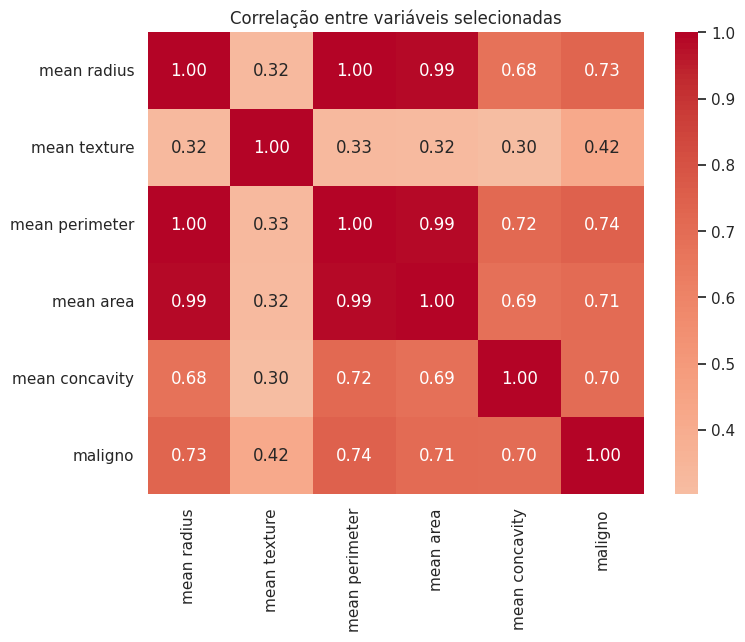

In [58]:
colunas_exemplo = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean concavity", "maligno"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas_exemplo].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre variáveis selecionadas")
plt.show()

### 1.6 Separação entre preditores e alvo

In [59]:
X = df.drop(columns="maligno")
y = df["maligno"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Proporção da classe positiva no treino:", y_train.mean().round(3))
print("Proporção da classe positiva no teste:", y_test.mean().round(3))

Treino: (426, 30)
Teste: (143, 30)
Proporção da classe positiva no treino: 0.373
Proporção da classe positiva no teste: 0.371


### 1.7 Pré-processamento e modelo linear

A regressão logística é um algoritmo de classificação linear. Como as variáveis estão em escalas diferentes, aplicamos padronização. O `Pipeline` garante que o escalonador seja ajustado somente com os dados de treino, reduzindo o risco de vazamento de dados.

In [60]:
modelo_logistico = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

modelo_logistico.fit(X_train, y_train)
y_pred_log = modelo_logistico.predict(X_test)
y_pred_log[:10]

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

### 1.8 Avaliação da regressão logística

Acurácia: 0.965


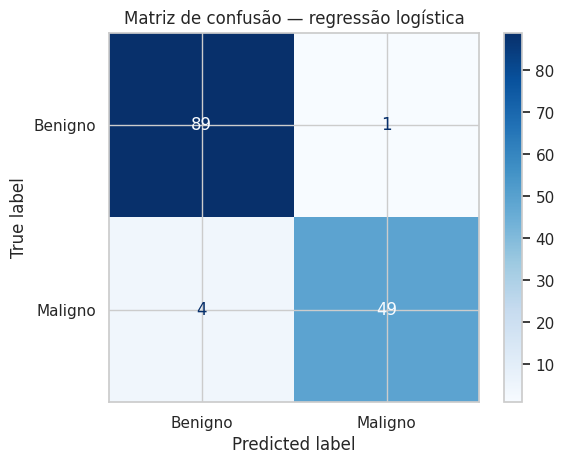

In [61]:
acuracia_log = accuracy_score(y_test, y_pred_log)
print(f"Acurácia: {acuracia_log:.3f}")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=["Benigno", "Maligno"],
    cmap="Blues"
)
plt.title("Matriz de confusão — regressão logística")
plt.show()

### 1.9 Comparação com outro algoritmo

A árvore de decisão não precisa de padronização para realizar suas divisões. O objetivo aqui não é declarar um vencedor universal, mas comparar o desempenho dos modelos no mesmo conjunto de teste.

In [62]:
modelo_arvore = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
modelo_arvore.fit(X_train, y_train)
y_pred_arvore = modelo_arvore.predict(X_test)
resultados = pd.DataFrame({
    "modelo": ["Regressão logística", "Árvore de decisão"],
    "acurácia": [acuracia_log, accuracy_score(y_test, y_pred_arvore)]
})

display(resultados.round(3))

,modelo,acurácia
0,Regressão logística,0.965
1,Árvore de decisão,0.895


### 1.10 Conclusão do exemplo

Os dois modelos foram treinados com os mesmos dados e comparados pela acurácia. A matriz de confusão permite observar quais classes foram confundidas. Mesmo com um bom resultado, este exercício é apenas didático e não permite utilizar o modelo para diagnóstico médico.

# Exercício 2 — Economia: classificação de faixa de renda
## Atividade guiada

Utilize o conjunto **Adult**, do UCI Machine Learning Repository. O objetivo é prever se a renda anual de uma pessoa pertence à classe `>50K` ou `<=50K`, com base em atributos censitários.

Página da fonte: <https://archive.ics.uci.edu/dataset/2/adult>

As células seguintes contêm apenas comentários orientadores. Substitua os comentários pelo código necessário, preservando as explicações em Markdown e registrando suas interpretações.

### 2.1 Carregar o arquivo CSV

O arquivo original do UCI (`adult.data`) **não possui linha de cabeçalho**, usa vírgula como separador, insere um
espaço depois de cada vírgula e representa valores ausentes pelo caractere `?`. Portanto, na leitura precisamos:

- passar a lista `names` com os nomes das 14 variáveis preditoras + a variável-alvo;
- usar `skipinitialspace=True` para remover o espaço após a vírgula (sem isso, `" Private"` e `"Private"` seriam
  categorias distintas);
- usar `na_values="?"` para que o pandas reconheça os ausentes como `NaN`.

O arquivo está versionado no repositório em `dados/adult.csv`. Caso não esteja presente, a célula faz o download
a partir de um espelho público e o salva localmente, garantindo que o notebook rode do início ao fim.

In [63]:
CAMINHO_ADULT = os.path.join(PASTA_DADOS, "adult.csv")
URL_ADULT = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"

if not os.path.exists(CAMINHO_ADULT):
    print("Arquivo local não encontrado. Baixando do espelho público...")
    urllib.request.urlretrieve(URL_ADULT, CAMINHO_ADULT)

colunas_adult = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country",
    "income",
]

df_adult = pd.read_csv(
    CAMINHO_ADULT,
    header=None,             # o arquivo original não tem cabeçalho
    names=colunas_adult,
    skipinitialspace=True,   # remove o espaço depois da vírgula
    na_values="?",           # marca os ausentes corretamente
)

print("Arquivo carregado:", CAMINHO_ADULT)
df_adult.head()

Arquivo carregado: dados/adult.csv


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 2.2 Realizar a inspeção inicial

In [64]:
print(f"Linhas: {df_adult.shape[0]}")
print(f"Colunas: {df_adult.shape[1]}")

display(df_adult.sample(5, random_state=RANDOM_STATE))

df_adult.info(memory_usage="deep")

print("\nVariável-alvo: 'income'")
print("Categorias encontradas:", df_adult["income"].unique())

Linhas: 48842
Colunas: 15


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
7762,18,Private,423024,HS-grad,9,Never-married,Other-service,Not-in-family,White,Male,0,0,20,United-States,<=50K
23881,17,Private,178953,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
30507,25,Local-gov,348986,HS-grad,9,Never-married,Handlers-cleaners,Other-relative,Black,Male,0,0,40,United-States,<=50K
28911,20,Private,218215,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,30,United-States,<=50K
19484,47,Private,244025,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,Amer-Indian-Eskimo,Male,0,0,56,Puerto-Rico,<=50K


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 26.4 MB

Variável-alvo: 'income'
Categorias encontradas: ['<=50K' '>50K']


**Variável-alvo identificada:** `income`, com duas categorias textuais (`<=50K` e `>50K`). As demais 14 colunas
são as variáveis preditoras: 6 numéricas e 8 categóricas.

### 2.3 Verificar a qualidade dos dados

In [65]:
qualidade_adult = pd.DataFrame({
    "tipo": df_adult.dtypes.astype(str),
    "ausentes": df_adult.isna().sum(),
    "percentual_ausentes": (df_adult.isna().mean() * 100).round(2),
    "valores_unicos": df_adult.nunique(),
})
display(qualidade_adult)

print("Registros duplicados:", df_adult.duplicated().sum())
print("Percentual de duplicados: "
      f"{df_adult.duplicated().mean() * 100:.3f}%")

# Valores observados nas colunas categóricas mais relevantes.
for coluna in ["workclass", "occupation", "native-country", "education"]:
    print(f"\n--- {coluna} ({df_adult[coluna].nunique()} categorias) ---")
    print(df_adult[coluna].value_counts(dropna=False).head(6))

,tipo,ausentes,percentual_ausentes,valores_unicos
age,int64,0,0.00,74
workclass,object,2799,5.73,8
fnlwgt,int64,0,0.00,28523
education,object,0,0.00,16
education-num,int64,0,0.00,16
marital-status,object,0,0.00,7
occupation,object,2809,5.75,14
relationship,object,0,0.00,6
race,object,0,0.00,5
sex,object,0,0.00,2


Registros duplicados: 52
Percentual de duplicados: 0.106%

--- workclass (8 categorias) ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Name: count, dtype: int64

--- occupation (14 categorias) ---
occupation
Prof-specialty     6172
Craft-repair       6112
Exec-managerial    6086
Adm-clerical       5611
Sales              5504
Other-service      4923
Name: count, dtype: int64

--- native-country (41 categorias) ---
native-country
United-States    43832
Mexico             951
NaN                857
Philippines        295
Germany            206
Puerto-Rico        184
Name: count, dtype: int64

--- education (16 categorias) ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Name: count, dtype: int64


In [66]:
# Decisão: remover os registros duplicados.
linhas_antes = df_adult.shape[0]
df_adult = df_adult.drop_duplicates().reset_index(drop=True)
print(f"Linhas antes: {linhas_antes} | depois: {df_adult.shape[0]} "
      f"| removidas: {linhas_antes - df_adult.shape[0]}")

Linhas antes: 48842 | depois: 48790 | removidas: 52


**Justificativa das decisões de qualidade:**

- **Ausentes:** aparecem apenas em `workclass`, `occupation` e `native-country`, sempre abaixo de 6% das linhas.
  Não removemos essas linhas: como o ausente se concentra em variáveis categóricas e pode ter significado próprio
  (por exemplo, pessoas fora do mercado formal de trabalho), optamos por **imputar** pela categoria mais frequente
  dentro do pipeline (etapa 2.7), evitando descartar milhares de registros.
- **Duplicados:** foram removidos. Como cada linha deveria representar um respondente distinto do censo, linhas
  idênticas em todas as 15 colunas são provavelmente repetição de registro e dariam peso indevido a esse perfil.
  O volume removido é irrisório (bem menos de 1%), portanto não altera a composição da base.
- **Valores inconsistentes:** as categorias das colunas textuais correspondem ao dicionário de dados do UCI; não
  há categorias fora do esperado além do `?` já convertido em `NaN`.

### 2.4 Desenvolver a análise exploratória

In [67]:
# Estatísticas descritivas das variáveis numéricas.
display(df_adult.describe().T.round(2))

# Distribuição absoluta e percentual da variável-alvo.
distribuicao_alvo = pd.DataFrame({
    "quantidade": df_adult["income"].value_counts(),
    "percentual": (df_adult["income"].value_counts(normalize=True) * 100).round(2),
})
display(distribuicao_alvo)

,count,mean,std,min,25%,50%,75%,max
age,48790.0,38.65,13.71,17.0,28.0,37.0,48.00,90.0
fnlwgt,48790.0,189669.00,105617.23,12285.0,117555.0,178138.5,237606.25,1490400.0
education-num,48790.0,10.08,2.57,1.0,9.0,10.0,12.00,16.0
capital-gain,48790.0,1080.22,7455.91,0.0,0.0,0.0,0.00,99999.0
capital-loss,48790.0,87.60,403.21,0.0,0.0,0.0,0.00,4356.0
hours-per-week,48790.0,40.43,12.39,1.0,40.0,40.0,45.00,99.0


,quantidade,percentual
income,,
<=50K,37109,76.06
>50K,11681,23.94


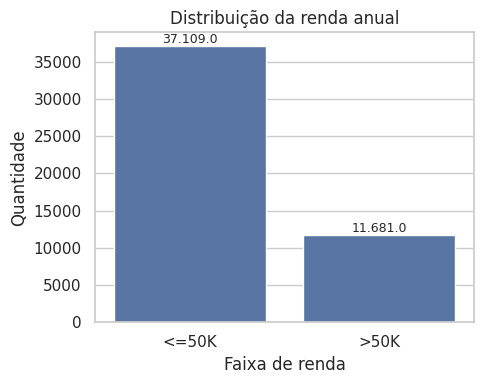

In [68]:
# Gráfico 1 — distribuição da variável-alvo.
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df_adult, x="income", color="#4C72B0")
ax.set(title="Distribuição da renda anual", xlabel="Faixa de renda", ylabel="Quantidade")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}".replace(",", "."),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

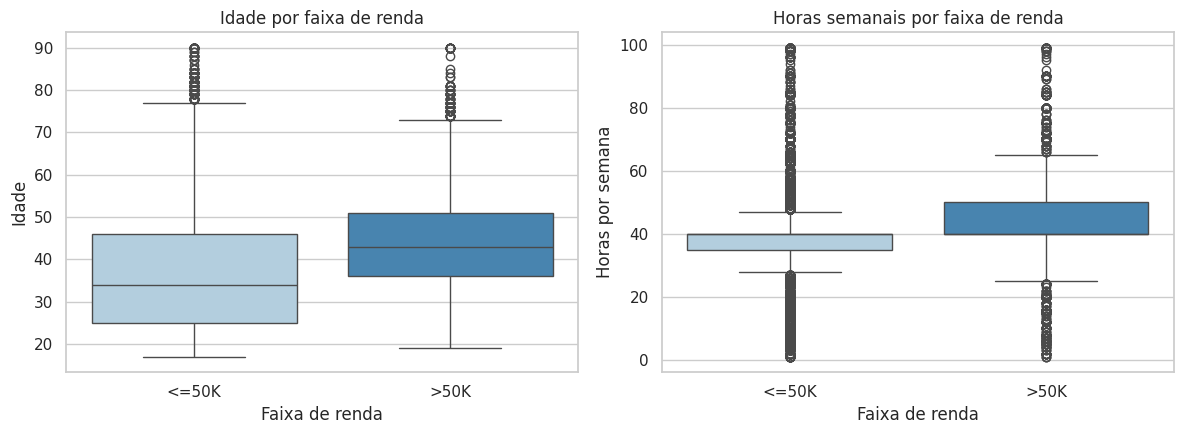

In [20]:
# Gráfico 2 — variável numérica (idade e horas semanais) versus a variável-alvo.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df_adult, x="income", y="age", ax=axes[0], palette="Blues")
axes[0].set(title="Idade por faixa de renda", xlabel="Faixa de renda", ylabel="Idade")

sns.boxplot(data=df_adult, x="income", y="hours-per-week", ax=axes[1], palette="Blues")
axes[1].set(title="Horas semanais por faixa de renda", xlabel="Faixa de renda", ylabel="Horas por semana")

plt.tight_layout()
plt.show()

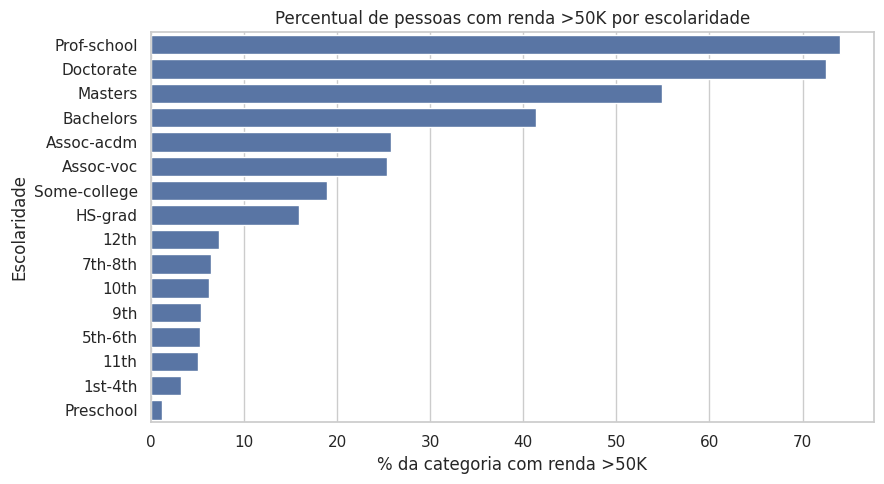

,percentual_acima_50K
education,
Prof-school,74.0
Doctorate,72.6
Masters,54.9
Bachelors,41.3
Assoc-acdm,25.8
Assoc-voc,25.3
Some-college,19.0
HS-grad,15.9
12th,7.3


In [21]:
# Gráfico 3 — variável categórica (escolaridade) versus a variável-alvo.
proporcao_educacao = (
    df_adult.groupby("education")["income"]
    .apply(lambda s: (s == ">50K").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=proporcao_educacao.values, y=proporcao_educacao.index, color="#4C72B0")
ax.set(title="Percentual de pessoas com renda >50K por escolaridade",
       xlabel="% da categoria com renda >50K", ylabel="Escolaridade")
plt.tight_layout()
plt.show()

display(proporcao_educacao.round(1).to_frame("percentual_acima_50K"))

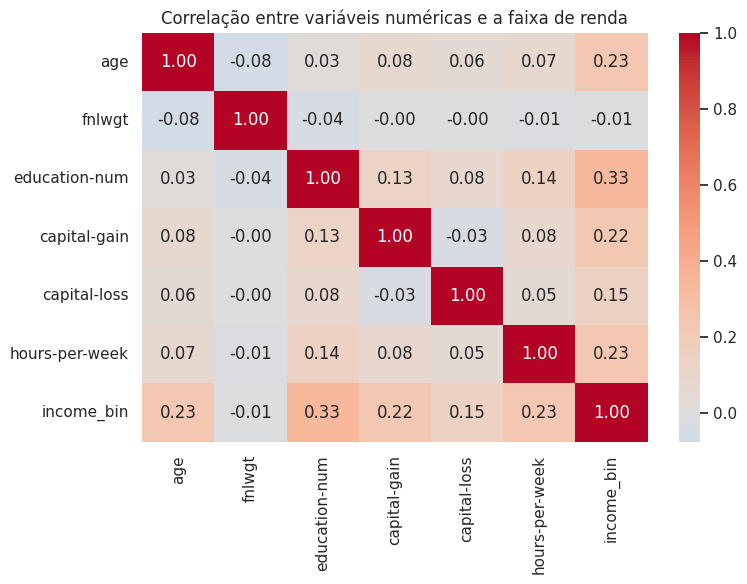

In [22]:
# Correlação entre as variáveis numéricas (inclui o alvo codificado apenas para leitura do gráfico).
numericas_adult = df_adult.select_dtypes(include="number").columns.tolist()
aux = df_adult[numericas_adult].copy()
aux["income_bin"] = (df_adult["income"] == ">50K").astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(aux.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre variáveis numéricas e a faixa de renda")
plt.tight_layout()
plt.show()

**Interpretação da análise exploratória:**

1. **A base é desbalanceada.** Cerca de três quartos dos registros pertencem à classe `<=50K`. Isso significa que
   um classificador que respondesse sempre `<=50K` já alcançaria aproximadamente 76% de acurácia — a acurácia
   sozinha, portanto, não é suficiente para julgar o modelo.
2. **A distribuição de idade difere entre as faixas.** A mediana de idade do grupo `>50K` é visivelmente mais alta
   e a dispersão é menor nas idades muito baixas. Isso é compatível com a ideia de que a renda tende a acompanhar
   o tempo de carreira, mas o gráfico não demonstra causalidade: idade e renda também são afetadas por escolaridade,
   ocupação e período histórico da coleta.
3. **Horas trabalhadas por semana acompanham a faixa de renda**, com mediana maior no grupo `>50K`. Ainda assim há
   grande sobreposição entre as duas distribuições, ou seja, essa variável isolada não separa as classes.
4. **A escolaridade está fortemente associada ao alvo.** Categorias de pós-graduação (`Doctorate`, `Prof-school`,
   `Masters`) apresentam os maiores percentuais de renda `>50K`, enquanto níveis fundamentais ficam próximos de zero.
   Novamente, trata-se de associação observada na amostra, não de relação de causa e efeito.
5. **Há redundância entre variáveis.** `education` e `education-num` codificam a mesma informação (texto e número),
   e `fnlwgt` é um peso amostral do censo, não um atributo da pessoa. Essas observações orientam decisões da
   próxima etapa.

### 2.5 Separar variáveis preditoras e alvo

In [23]:
# Colunas descartadas, com justificativa:
# - fnlwgt: peso amostral atribuído pelo censo, não descreve o indivíduo.
# - education: redundante com education-num, que já é a versão ordinal da mesma informação.
colunas_descartadas = ["fnlwgt", "education"]

X_adult = df_adult.drop(columns=["income"] + colunas_descartadas)
y_adult = (df_adult["income"] == ">50K").astype(int)   # 1 = >50K (classe de interesse), 0 = <=50K

print("Dimensões de X:", X_adult.shape)
print("Dimensões de y:", y_adult.shape)
print("\nDistribuição de y:")
print(y_adult.value_counts(normalize=True).round(4))
display(X_adult.head())

Dimensões de X: (48790, 12)
Dimensões de y: (48790,)

Distribuição de y:
income
0    0.7606
1    0.2394
Name: proportion, dtype: float64


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


### 2.6 Dividir os dados

In [24]:
X_train_ad, X_test_ad, y_train_ad, y_test_ad = train_test_split(
    X_adult,
    y_adult,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_adult,
)

print("Treino:", X_train_ad.shape, "| Teste:", X_test_ad.shape)

comparacao_proporcoes = pd.DataFrame({
    "treino": y_train_ad.value_counts(normalize=True).sort_index().round(4),
    "teste": y_test_ad.value_counts(normalize=True).sort_index().round(4),
})
comparacao_proporcoes.index = ["<=50K (0)", ">50K (1)"]
display(comparacao_proporcoes)

Treino: (36592, 12) | Teste: (12198, 12)


,treino,teste
<=50K (0),0.7606,0.7606
>50K (1),0.2394,0.2394


O parâmetro `stratify=y_adult` preserva a proporção das classes nos dois subconjuntos, como confirmado pela tabela.
Sem isso, uma divisão aleatória poderia deixar treino e teste com prevalências diferentes e distorcer a comparação.

### 2.7 Realizar o pré-processamento básico

In [25]:
# Identificação dos tipos de coluna a partir das numéricas (evita depender do nome do dtype de texto,
# que mudou entre versões do pandas).
num_adult = X_adult.select_dtypes(include="number").columns.tolist()
cat_adult = [c for c in X_adult.columns if c not in num_adult]

print("Numéricas  ", len(num_adult), ":", num_adult)
print("Categóricas", len(cat_adult), ":", cat_adult)

Numéricas   5 : ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categóricas 7 : ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [26]:
# Pipeline de pré-processamento:
#  - numéricas  -> imputação pela mediana + padronização (necessária para a regressão logística)
#  - categóricas -> imputação pela categoria mais frequente + One-Hot Encoding
pipeline_num_adult = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="median")),
    ("escala", StandardScaler()),
])

pipeline_cat_adult = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessador_adult = ColumnTransformer(transformers=[
    ("num", pipeline_num_adult, num_adult),
    ("cat", pipeline_cat_adult, cat_adult),
])

# Conferência do resultado: ajustamos SOMENTE com os dados de treino.
X_train_transformado = preprocessador_adult.fit_transform(X_train_ad)
print("Formato após o pré-processamento (treino):", X_train_transformado.shape)
print("Formato após o pré-processamento (teste):",
      preprocessador_adult.transform(X_test_ad).shape)
print("Ausentes restantes no treino transformado:",
      int(np.isnan(X_train_transformado.toarray()).sum())
      if hasattr(X_train_transformado, "toarray") else int(np.isnan(X_train_transformado).sum()))

Formato após o pré-processamento (treino): (36592, 88)
Formato após o pré-processamento (teste): (12198, 88)
Ausentes restantes no treino transformado: 0


**Decisões de pré-processamento:**

- **Imputação.** As três colunas com ausentes são categóricas; usamos a categoria mais frequente. Para as numéricas
  incluímos a imputação pela mediana por segurança — ela não altera nada nesta base (não há ausentes numéricos), mas
  torna o pipeline robusto caso o CSV mude.
- **Padronização.** A regressão logística é sensível à escala das variáveis: `capital-gain` chega à casa das dezenas
  de milhares enquanto `education-num` vai de 1 a 16. Sem padronizar, a otimização converge mal e os coeficientes
  ficam incomparáveis entre si.
- **One-Hot Encoding.** As categóricas não têm ordem natural (`occupation`, `native-country`). Codificá-las com
  números inteiros inventaria uma ordem inexistente; o One-Hot cria uma coluna binária por categoria.
  `handle_unknown="ignore"` evita erro caso uma categoria apareça só no teste.
- **Ajuste apenas no treino.** Todo o pré-processamento vive dentro do `ColumnTransformer` e será encaixado em um
  `Pipeline` junto do modelo. Assim medianas, modas e médias/desvios são calculados exclusivamente sobre o treino,
  o que evita vazamento de informação do conjunto de teste.

### 2.8 Treinar um modelo linear

In [27]:
modelo_log_adult = Pipeline(steps=[
    ("preprocessamento", preprocessador_adult),
    ("modelo", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

modelo_log_adult.fit(X_train_ad, y_train_ad)
y_pred_log_adult = modelo_log_adult.predict(X_test_ad)

print("Modelo treinado.")
print("Primeiras 15 previsões:", y_pred_log_adult[:15])
print("Primeiros 15 valores reais:", y_test_ad.values[:15])

Modelo treinado.
Primeiras 15 previsões: [1 0 0 0 0 1 1 0 0 0 0 0 0 0 1]
Primeiros 15 valores reais: [1 0 1 0 0 1 0 1 0 0 1 1 0 0 1]


### 2.9 Avaliar o modelo

Acurácia da regressão logística: 0.8537
Acurácia da linha de base (sempre <=50K): 0.7606


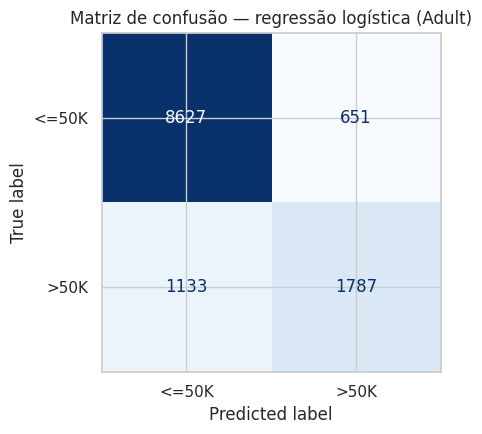

              precision    recall  f1-score   support

       <=50K      0.884     0.930     0.906      9278
        >50K      0.733     0.612     0.667      2920

    accuracy                          0.854     12198
   macro avg      0.808     0.771     0.787     12198
weighted avg      0.848     0.854     0.849     12198



In [28]:
acuracia_log_adult = accuracy_score(y_test_ad, y_pred_log_adult)
print(f"Acurácia da regressão logística: {acuracia_log_adult:.4f}")

# Linha de base: prever sempre a classe majoritária.
baseline_adult = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_adult.fit(X_train_ad, y_train_ad)
acuracia_baseline_adult = accuracy_score(y_test_ad, baseline_adult.predict(X_test_ad))
print(f"Acurácia da linha de base (sempre <=50K): {acuracia_baseline_adult:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test_ad, y_pred_log_adult,
    display_labels=["<=50K", ">50K"], cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Matriz de confusão — regressão logística (Adult)")
plt.tight_layout()
plt.show()

print(classification_report(y_test_ad, y_pred_log_adult,
                            target_names=["<=50K", ">50K"], digits=3))

**O que o resultado mostra:**

A acurácia fica em torno de 0,85, contra aproximadamente 0,76 da linha de base que responde sempre `<=50K`.
O modelo, portanto, aprendeu algo além da classe majoritária, mas o ganho é mais modesto do que o número absoluto
sugere.

A matriz de confusão detalha esse comportamento. A classe `<=50K` é reconhecida com facilidade (revocação acima de
0,92). A classe `>50K` é a difícil: uma parte relevante das pessoas com renda alta é classificada como renda baixa
(falsos negativos), e a revocação dessa classe fica próxima de 0,60. Isso é esperado em uma base desbalanceada:
o modelo é otimizado para o erro total e "paga barato" errando na classe rara.

Na prática, isso significa que a acurácia global esconde um desempenho desigual entre as classes. Precisão e
revocação por classe, exibidas no `classification_report`, descrevem melhor o comportamento do modelo.

### 2.10 Comparar com um segundo algoritmo

In [29]:
# Segundo algoritmo: Random Forest, mantendo exatamente a mesma divisão treino/teste.
modelo_rf_adult = Pipeline(steps=[
    ("preprocessamento", preprocessador_adult),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

modelo_rf_adult.fit(X_train_ad, y_train_ad)
y_pred_rf_adult = modelo_rf_adult.predict(X_test_ad)

resultados_adult = pd.DataFrame({
    "modelo": ["Linha de base (classe majoritária)", "Regressão logística", "Random Forest"],
    "acurácia": [
        acuracia_baseline_adult,
        acuracia_log_adult,
        accuracy_score(y_test_ad, y_pred_rf_adult),
    ],
    "revocação (>50K)": [
        recall_score(y_test_ad, baseline_adult.predict(X_test_ad), zero_division=0),
        recall_score(y_test_ad, y_pred_log_adult),
        recall_score(y_test_ad, y_pred_rf_adult),
    ],
    "precisão (>50K)": [
        precision_score(y_test_ad, baseline_adult.predict(X_test_ad), zero_division=0),
        precision_score(y_test_ad, y_pred_log_adult),
        precision_score(y_test_ad, y_pred_rf_adult),
    ],
    "F1 (>50K)": [
        f1_score(y_test_ad, baseline_adult.predict(X_test_ad), zero_division=0),
        f1_score(y_test_ad, y_pred_log_adult),
        f1_score(y_test_ad, y_pred_rf_adult),
    ],
})

display(resultados_adult.round(4))

melhor_adult = resultados_adult.loc[resultados_adult["acurácia"].idxmax(), "modelo"]
print("Maior acurácia nesta divisão dos dados:", melhor_adult)

,modelo,acurácia,revocação (>50K),precisão (>50K),F1 (>50K)
0,Linha de base (classe majoritária),0.7606,0.0000,0.0000,0.0000
1,Regressão logística,0.8537,0.6120,0.7330,0.6670
2,Random Forest,0.8668,0.6236,0.7759,0.6915


Maior acurácia nesta divisão dos dados: Random Forest


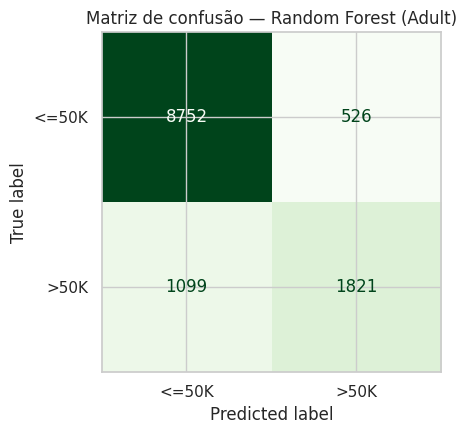

In [30]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test_ad, y_pred_rf_adult,
    display_labels=["<=50K", ">50K"], cmap="Greens", ax=ax, colorbar=False
)
ax.set_title("Matriz de confusão — Random Forest (Adult)")
plt.tight_layout()
plt.show()

### 2.11 Conclusão do Exercício 2

**1. Qual modelo apresentou a maior acurácia?**
O Random Forest apresentou a maior acurácia no conjunto de teste (0,867), com vantagem de cerca de 1,3 ponto
percentual sobre a regressão logística (0,854). Os dois ficaram bem acima da linha de base de 0,761. A diferença entre os
dois modelos é pequena e vale apenas para esta divisão específica dos dados: com outra semente ou com validação
cruzada a ordem poderia mudar.

**2. O resultado foi semelhante para as duas classes?**
Não. Nos dois modelos a classe `<=50K` é prevista muito melhor do que a classe `>50K`. A revocação da classe
majoritária fica acima de 0,92, enquanto a da classe `>50K` fica em torno de 0,6. Essa assimetria é consequência
direta do desbalanceamento (76% contra 24%) somada ao fato de que ambos os algoritmos, por padrão, minimizam o
erro total sem penalizar mais o erro na classe rara.

**3. O que a matriz de confusão mostrou?**
Mostrou que o erro dominante é o **falso negativo**: pessoas que ganham mais de 50 mil classificadas como
`<=50K`. Os falsos positivos existem, mas em menor quantidade. Se a aplicação real dependesse de identificar
corretamente quem tem renda alta (por exemplo, para uma política pública ou uma análise de crédito), esse padrão
seria um problema sério e a acurácia global daria uma impressão otimista demais.

**4. Qual é a principal limitação desta análise?**
São dados do censo americano de 1994. As distribuições de ocupação, escolaridade e renda mudaram muito desde
então, e a variável de corte (50 mil dólares) não corresponde ao mesmo poder de compra hoje — o modelo não pode
ser transportado para outro país ou período. Além disso, a base contém atributos sensíveis (`race`, `sex`,
`native-country`) e o modelo aprende as associações históricas presentes nesses dados, incluindo desigualdades;
usar essas previsões para decidir sobre pessoas reproduziria esses padrões. Por fim, avaliamos apenas uma divisão
treino/teste e não fizemos ajuste de hiperparâmetros, então as métricas têm incerteza que não foi quantificada.

# Exercício 3 — Desafio real
## Construção e demonstração de uma solução de classificação

Cada grupo deve escolher **um** dos quatro temas abaixo. A base deve ser obtida em formato CSV ou convertida para CSV antes da análise. O grupo deverá construir uma solução completa, sem reutilizar diretamente o código resolvido.

| Tema | Dataset sugerido | Problema de classificação |
|---|---|---|
| Saúde | Parkinson's — UCI | Classificar registros de voz associados ou não à doença de Parkinson (`status`). |
| Economia | Bank Marketing — UCI | Prever se um cliente contratará um depósito a prazo (`y`). |
| Energia | Electrical Grid Stability — UCI | Classificar a rede simulada como estável ou instável (`stabf`). |
| Telecomunicações | Iranian Churn — UCI | Prever a ocorrência de evasão de clientes (`Churn`). |

### Fontes

- Saúde: <https://archive.ics.uci.edu/dataset/174/parkinsons>
- Economia: <https://archive.ics.uci.edu/dataset/222/bank+marketing>
- Energia: <https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data>
- Telecomunicações: <https://archive.ics.uci.edu/dataset/563/iranian+churn>

O grupo pode propor outro dataset Kaggle ou UCI dentro de um dos quatro temas, desde que obtenha aprovação do professor e identifique claramente a fonte, a variável-alvo e o significado de cada classe.

## 3.1 Definição do problema

- **Tema escolhido:** Economia — *Bank Marketing*.

- **Fonte e link do dataset:** UCI Machine Learning Repository, *Bank Marketing Data Set*
  (Moro, S., Rita, P. e Cortez, P., 2014) — <https://archive.ics.uci.edu/dataset/222/bank+marketing>.
  Arquivo utilizado: `bank-full.csv` (45.211 registros, 16 variáveis preditoras, separador `;`).
  O arquivo está versionado no repositório em `dados/bank-full.csv`.

- **Unidade representada por cada linha:** um **contato telefônico** de uma campanha de telemarketing de um banco
  português, realizado entre maio de 2008 e novembro de 2010. A linha reúne dados cadastrais do cliente e o
  histórico de contatos da campanha.

- **Variável-alvo:** `y` — indica se o cliente contratou o depósito a prazo após aquele contato.

- **Significado das classes:**
  - `yes` (codificada como **1**) — o cliente **contratou** o depósito a prazo. É a classe de interesse.
  - `no` (codificada como **0**) — o cliente **não contratou**.

- **Decisão que o modelo pretende apoiar:** priorizar a lista de clientes a serem contactados pela equipe de
  telemarketing. Cada ligação tem custo (tempo do operador) e desgasta a relação com o cliente; ordenar a lista
  por probabilidade de contratação permite gastar o mesmo esforço com retorno maior.

- **Possíveis consequências de falsos positivos** (o modelo prevê contratação e o cliente não contrata):
  desperdício de tempo da equipe, custo de ligação sem retorno e incômodo para o cliente, que pode reduzir a
  eficácia de campanhas futuras. É o erro **mais barato** neste contexto.

- **Possíveis consequências de falsos negativos** (o modelo prevê que não contrata e o cliente contrataria):
  o cliente deixa de ser contactado e o banco perde uma venda que teria acontecido. É uma **receita perdida** e,
  por ser invisível, nunca aparece no relatório da campanha. Como o objetivo é encontrar os poucos clientes
  interessados dentro de uma base majoritariamente desinteressada, este é o erro **mais caro** — por isso vamos
  acompanhar de perto a revocação da classe `yes`, e não apenas a acurácia.

## 3.2 Requisitos da implementação

O notebook do grupo deve conter, nesta ordem:

1. carga dos dados a partir de um arquivo CSV;
2. descrição do dataset e da variável-alvo;
3. inspeção de dimensões, tipos e amostra;
4. verificação de ausentes, duplicados e valores inconsistentes;
5. análise da distribuição das classes;
6. pelo menos três visualizações relevantes;
7. separação entre `X` e `y`;
8. divisão entre treino e teste;
9. pré-processamento adequado aos tipos de variáveis;
10. treinamento de uma regressão logística;
11. treinamento de pelo menos um segundo algoritmo do `scikit-learn`;
12. comparação da acurácia dos modelos;
13. matriz de confusão;
14. conclusão com o resultado e as limitações.

### Condições técnicas

- Não remova valores ou variáveis sem justificar.
- Caso crie uma classe a partir de uma variável numérica, documente o limiar e evite vazamento dessa variável para os preditores.

## 3.3 Desenvolvimento

### 3.3.1 Carga dos dados a partir do arquivo CSV

O arquivo `bank-full.csv` do UCI usa **ponto e vírgula** como separador e envolve os textos em aspas duplas.
Por isso a leitura precisa de `sep=";"`. O arquivo já possui cabeçalho.

In [31]:
CAMINHO_BANK = os.path.join(PASTA_DADOS, "bank-full.csv")
URL_BANK = ("https://raw.githubusercontent.com/khatrideepti/"
            "Bank-Marketing-Data-Analysis/master/bank-full.csv")

if not os.path.exists(CAMINHO_BANK):
    print("Arquivo local não encontrado. Baixando do espelho público...")
    urllib.request.urlretrieve(URL_BANK, CAMINHO_BANK)

banco = pd.read_csv(CAMINHO_BANK, sep=";")   # separador ';' é essencial nesta base

print("Arquivo carregado:", CAMINHO_BANK)
banco.head()

Arquivo local não encontrado. Baixando do espelho público...
Arquivo carregado: dados/bank-full.csv


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### 3.3.2 Descrição do dataset e da variável-alvo

**Variáveis do cliente (cadastro):**

| Variável | Tipo | Descrição |
|---|---|---|
| `age` | numérica | idade do cliente |
| `job` | categórica | tipo de ocupação (12 categorias) |
| `marital` | categórica | estado civil |
| `education` | categórica | escolaridade (`primary`, `secondary`, `tertiary`, `unknown`) |
| `default` | categórica | possui crédito em atraso? |
| `balance` | numérica | saldo médio anual da conta, em euros |
| `housing` | categórica | possui financiamento imobiliário? |
| `loan` | categórica | possui empréstimo pessoal? |

**Variáveis do contato e da campanha:**

| Variável | Tipo | Descrição |
|---|---|---|
| `contact` | categórica | meio de contato (`cellular`, `telephone`, `unknown`) |
| `day` | numérica | dia do mês do último contato |
| `month` | categórica | mês do último contato |
| `duration` | numérica | duração do último contato, em segundos |
| `campaign` | numérica | número de contatos feitos nesta campanha para este cliente |
| `pdays` | numérica | dias desde o último contato de uma campanha anterior (`-1` = nunca contactado) |
| `previous` | numérica | número de contatos anteriores a esta campanha |
| `poutcome` | categórica | resultado da campanha anterior |

**Variável-alvo:** `y` (`yes` / `no`) — contratação do depósito a prazo. Será codificada como `1` para `yes`
(classe de interesse) e `0` para `no`.

> **Observação importante sobre `pdays`:** o valor `-1` não é um número negativo de dias, é um **código de ausência**
> ("cliente nunca contactado antes"). Trataremos esse caso explicitamente na etapa de pré-processamento.

### 3.3.3 Inspeção de dimensões, tipos e amostra

In [32]:
print(f"Linhas: {banco.shape[0]:,}".replace(",", "."))
print(f"Colunas: {banco.shape[1]}")

display(banco.sample(5, random_state=RANDOM_STATE))

banco.info(memory_usage="deep")

Linhas: 45.211
Colunas: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
3776,40,blue-collar,married,secondary,no,580,yes,no,unknown,16,may,192,1,-1,0,unknown,no
9928,47,services,single,secondary,no,3644,no,no,unknown,9,jun,83,2,-1,0,unknown,no
33409,25,student,single,tertiary,no,538,yes,no,cellular,20,apr,226,1,-1,0,unknown,no
31885,42,management,married,tertiary,no,1773,no,no,cellular,9,apr,311,1,336,1,failure,no
15738,56,management,married,tertiary,no,217,no,yes,cellular,21,jul,121,2,-1,0,unknown,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 25.7 MB


### 3.3.4 Ausentes, duplicados e valores inconsistentes

In [33]:
qualidade_banco = pd.DataFrame({
    "tipo": banco.dtypes.astype(str),
    "ausentes": banco.isna().sum(),
    "percentual_ausentes": (banco.isna().mean() * 100).round(2),
    "valores_unicos": banco.nunique(),
})
display(qualidade_banco)

print("Registros duplicados:", banco.duplicated().sum())

,tipo,ausentes,percentual_ausentes,valores_unicos
age,int64,0,0.0,77
job,object,0,0.0,12
marital,object,0,0.0,3
education,object,0,0.0,4
default,object,0,0.0,2
balance,int64,0,0.0,7168
housing,object,0,0.0,2
loan,object,0,0.0,2
contact,object,0,0.0,3
day,int64,0,0.0,31


Registros duplicados: 0


In [34]:
# A base não usa NaN: valores desconhecidos aparecem como a categoria textual "unknown".
categoricas_banco = [c for c in banco.columns
                     if c not in banco.select_dtypes(include="number").columns]

print("Ocorrências de 'unknown' por coluna categórica:\n")
for coluna in categoricas_banco:
    n_unknown = (banco[coluna] == "unknown").sum()
    if n_unknown:
        print(f"  {coluna:<12} {n_unknown:>6} registros "
              f"({n_unknown / len(banco) * 100:5.2f}%)")

print("\nCategorias observadas:")
for coluna in categoricas_banco:
    print(f"  {coluna:<12} ({banco[coluna].nunique():2d}): {sorted(banco[coluna].unique())}")

Ocorrências de 'unknown' por coluna categórica:

  job             288 registros ( 0.64%)
  education      1857 registros ( 4.11%)
  contact       13020 registros (28.80%)
  poutcome      36959 registros (81.75%)

Categorias observadas:
  job          (12): ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
  marital      ( 3): ['divorced', 'married', 'single']
  education    ( 4): ['primary', 'secondary', 'tertiary', 'unknown']
  default      ( 2): ['no', 'yes']
  housing      ( 2): ['no', 'yes']
  loan         ( 2): ['no', 'yes']
  contact      ( 3): ['cellular', 'telephone', 'unknown']
  month        (12): ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
  poutcome     ( 4): ['failure', 'other', 'success', 'unknown']
  y            ( 2): ['no', 'yes']


In [35]:
# Verificação de valores fora do esperado nas variáveis numéricas.
display(banco.describe().T.round(2))

print("pdays == -1 (nunca contactado antes):",
      f"{(banco['pdays'] == -1).sum():,}".replace(",", "."),
      f"({(banco['pdays'] == -1).mean() * 100:.1f}%)")
print("balance negativo (conta no vermelho):",
      f"{(banco['balance'] < 0).sum():,}".replace(",", "."),
      f"({(banco['balance'] < 0).mean() * 100:.1f}%)")
print("duration == 0 (ligação sem conversa):", (banco["duration"] == 0).sum())
print("campaign máximo (contatos na campanha):", banco["campaign"].max())

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


pdays == -1 (nunca contactado antes): 36.954 (81.7%)
balance negativo (conta no vermelho): 3.766 (8.3%)
duration == 0 (ligação sem conversa): 3
campaign máximo (contatos na campanha): 63


**Diagnóstico de qualidade e decisões tomadas:**

- **Nenhum valor `NaN` e nenhuma linha duplicada.** A base já vem consistente; não foi necessário remover registros.
- **Os "ausentes" estão codificados como a categoria `unknown`** em `job`, `education`, `contact` e `poutcome`.
  **Decisão: manter `unknown` como categoria própria**, em vez de imputar. O motivo é que a ausência aqui é
  informativa. O caso mais claro é `poutcome`: dos 36.959 registros marcados como `unknown`, 36.954 têm também
  `pdays = -1`, ou seja, esse `unknown` não é um dado perdido — significa "não houve campanha anterior".
  Em `contact` (28,8% de `unknown`), o rótulo indica que o meio de contato não foi registrado, e essa própria
  ausência de registro está associada a uma taxa de contratação muito baixa (4,1%, contra 14,9% em `cellular`).
  Substituir pela moda destruiria essa informação e inventaria um dado que não existe.
- **`balance` negativo é válido** (conta com saldo devedor), não é erro de digitação. Mantido.
- **`pdays = -1` é código de ausência**, não uma quantidade. Vamos criar a variável binária `contactado_antes` e
  substituir o `-1` por `0` em `pdays`, para que o valor não seja interpretado como "um dia antes do contato".
- **Não removemos outliers** de `balance`, `duration` ou `campaign`. Os valores extremos são plausíveis
  (clientes com saldo muito alto, ligações longas) e removê-los sem uma regra de negócio seria descartar
  informação real da base.

### 3.3.5 Distribuição das classes

In [36]:
distribuicao_y = pd.DataFrame({
    "quantidade": banco["y"].value_counts(),
    "percentual": (banco["y"].value_counts(normalize=True) * 100).round(2),
})
display(distribuicao_y)

taxa_conversao = (banco["y"] == "yes").mean()
print(f"Taxa de contratação da campanha: {taxa_conversao * 100:.2f}%")
print(f"Acurácia de um modelo que responda sempre 'no': {(1 - taxa_conversao) * 100:.2f}%")

,quantidade,percentual
y,,
no,39922,88.3
yes,5289,11.7


Taxa de contratação da campanha: 11.70%
Acurácia de um modelo que responda sempre 'no': 88.30%


**Interpretação:** a base é fortemente desbalanceada — aproximadamente **88% de `no` contra 12% de `yes`**.
Esse número define a régua da avaliação: **qualquer modelo com menos de ~88% de acurácia é pior do que simplesmente
não ligar para ninguém.** É por isso que, ao longo de todo o Exercício 3, a acurácia será reportada sempre ao lado
da revocação e da precisão da classe `yes`.

### 3.3.6 Visualizações

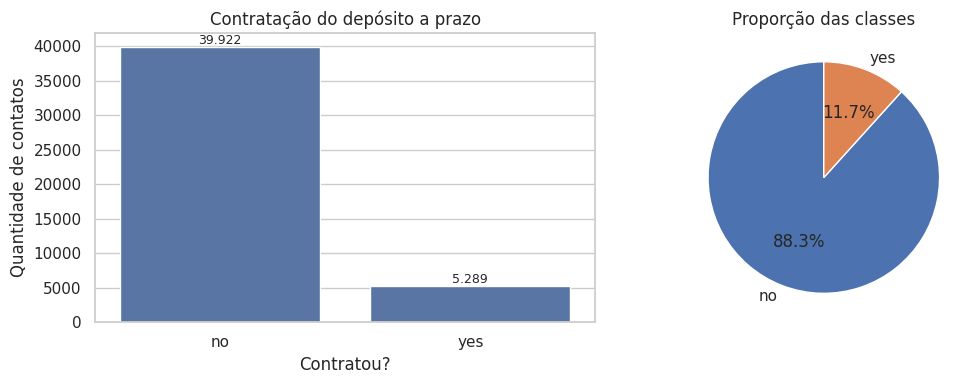

In [37]:
# Visualização 1 — distribuição da variável-alvo.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = sns.countplot(data=banco, x="y", order=["no", "yes"], color="#4C72B0", ax=axes[0])
ax.set(title="Contratação do depósito a prazo", xlabel="Contratou?", ylabel="Quantidade de contatos")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}".replace(",", "."),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)

axes[1].pie(banco["y"].value_counts(), labels=["no", "yes"], autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Proporção das classes")

plt.tight_layout()
plt.show()

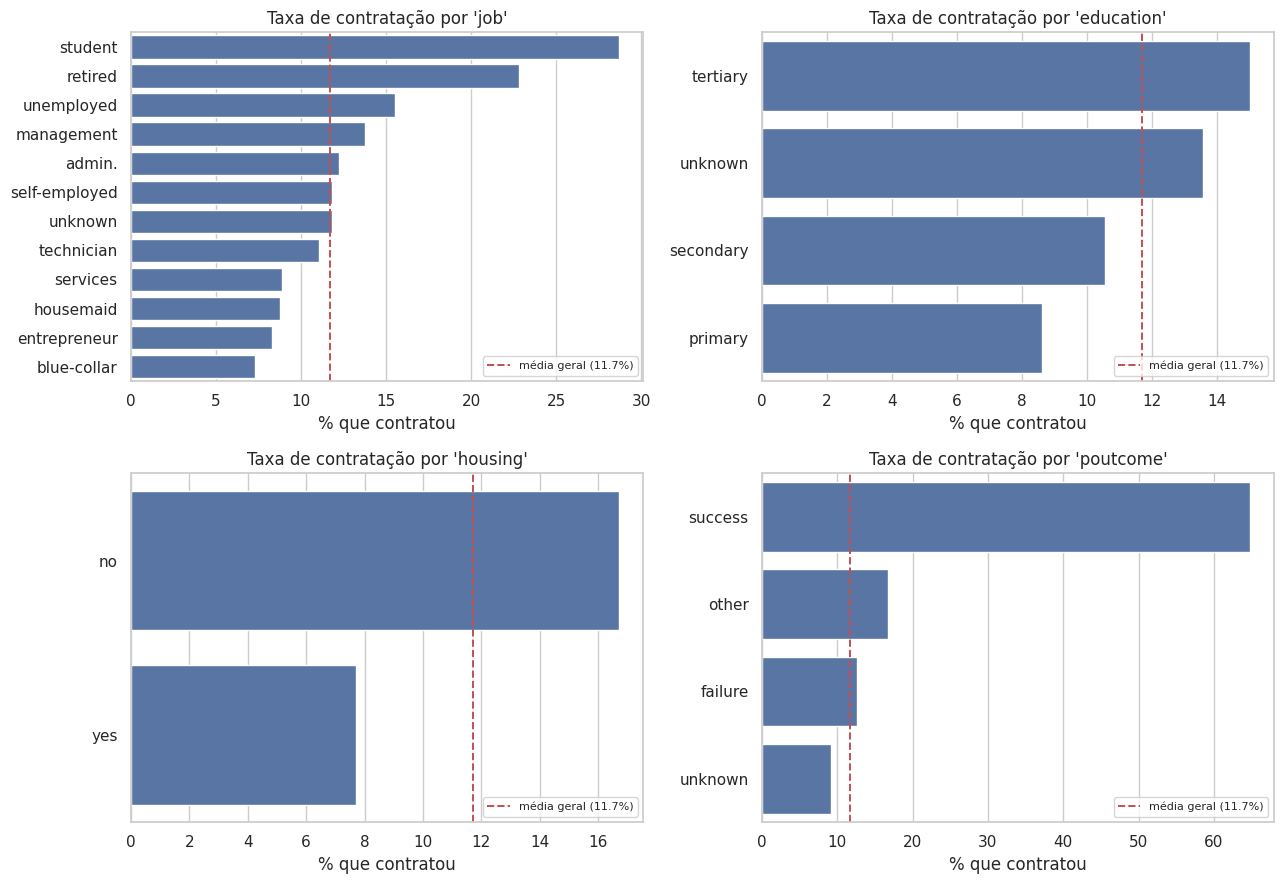

In [38]:
# Visualização 2 — taxa de contratação por categoria (variáveis categóricas do cliente e da campanha).
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, coluna in zip(axes.ravel(), ["job", "education", "housing", "poutcome"]):
    taxa = (banco.groupby(coluna)["y"]
            .apply(lambda s: (s == "yes").mean() * 100)
            .sort_values(ascending=False))
    sns.barplot(x=taxa.values, y=taxa.index, color="#4C72B0", ax=ax)
    ax.axvline(taxa_conversao * 100, color="#C44E52", linestyle="--", linewidth=1.4,
               label=f"média geral ({taxa_conversao * 100:.1f}%)")
    ax.set(title=f"Taxa de contratação por '{coluna}'", xlabel="% que contratou", ylabel="")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

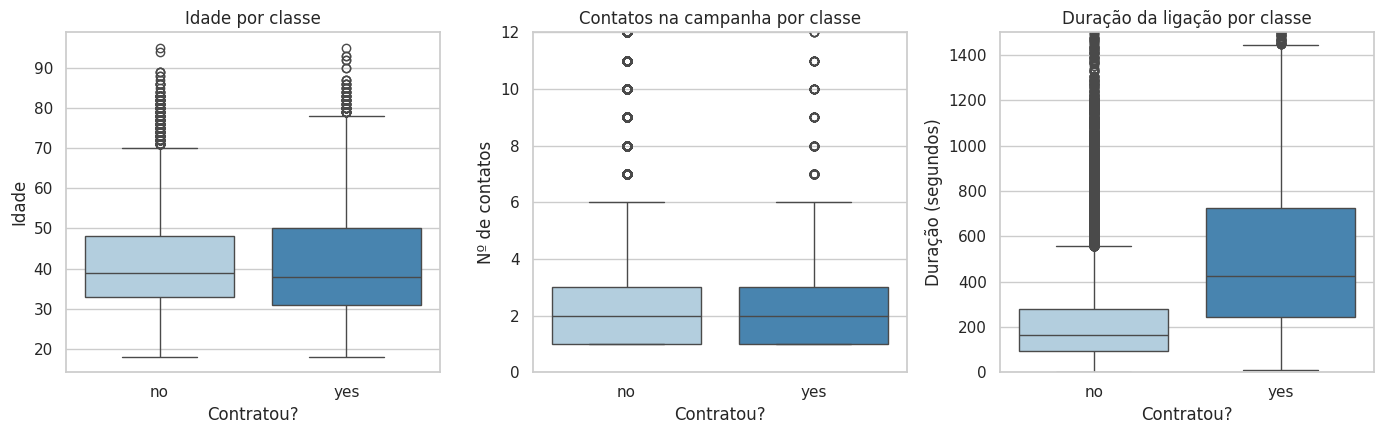

In [39]:
# Visualização 3 — variáveis numéricas por classe.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

sns.boxplot(data=banco, x="y", y="age", order=["no", "yes"], palette="Blues", ax=axes[0])
axes[0].set(title="Idade por classe", xlabel="Contratou?", ylabel="Idade")

sns.boxplot(data=banco, x="y", y="campaign", order=["no", "yes"], palette="Blues", ax=axes[1])
axes[1].set(title="Contatos na campanha por classe", xlabel="Contratou?",
            ylabel="Nº de contatos", ylim=(0, 12))

sns.boxplot(data=banco, x="y", y="duration", order=["no", "yes"], palette="Blues", ax=axes[2])
axes[2].set(title="Duração da ligação por classe", xlabel="Contratou?",
            ylabel="Duração (segundos)", ylim=(0, 1500))

plt.tight_layout()
plt.show()

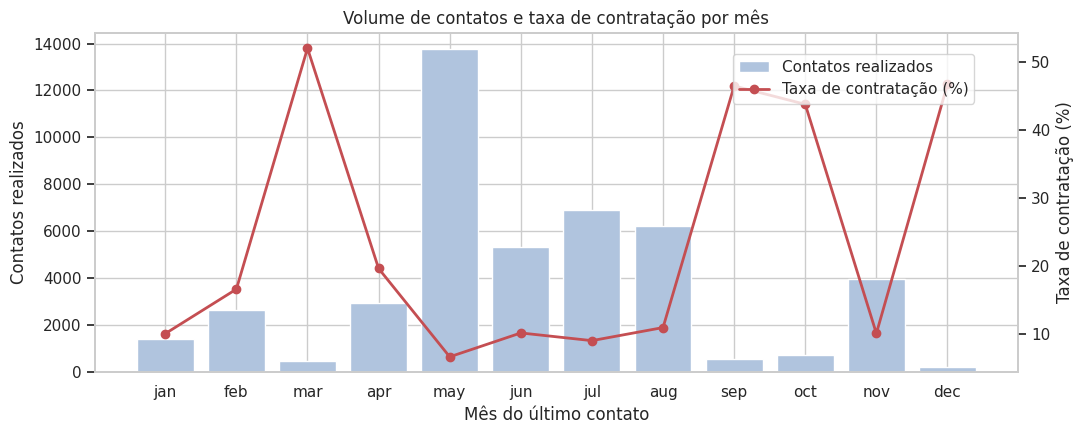

In [40]:
# Visualização 4 — sazonalidade: volume de contatos e taxa de contratação por mês.
ordem_meses = ["jan", "feb", "mar", "apr", "may", "jun",
               "jul", "aug", "sep", "oct", "nov", "dec"]

volume_mes = banco["month"].value_counts().reindex(ordem_meses)
taxa_mes = (banco.groupby("month")["y"]
            .apply(lambda s: (s == "yes").mean() * 100)
            .reindex(ordem_meses))

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(ordem_meses, volume_mes.values, color="#B0C4DE", label="Contatos realizados")
ax1.set_ylabel("Contatos realizados")
ax1.set_xlabel("Mês do último contato")

ax2 = ax1.twinx()
ax2.plot(ordem_meses, taxa_mes.values, color="#C44E52", marker="o", linewidth=2,
         label="Taxa de contratação (%)")
ax2.set_ylabel("Taxa de contratação (%)")
ax2.grid(False)

ax1.set_title("Volume de contatos e taxa de contratação por mês")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

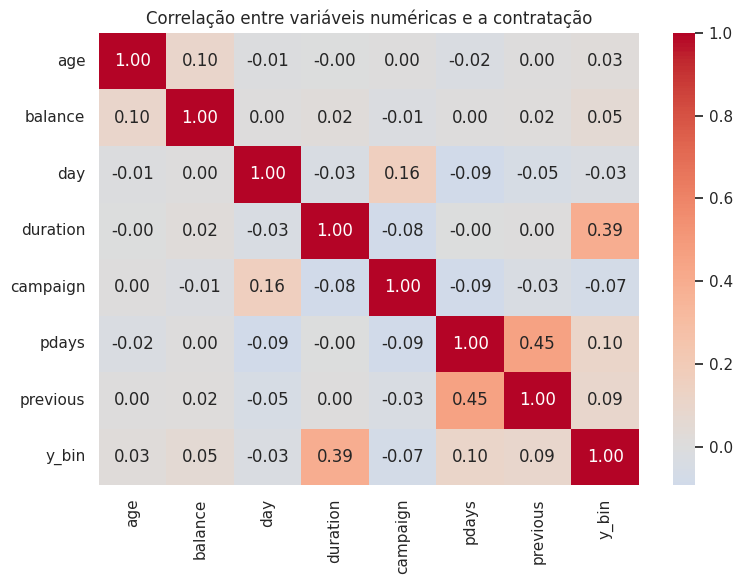

In [41]:
# Visualização 5 — correlação entre as variáveis numéricas e o alvo codificado.
numericas_banco = banco.select_dtypes(include="number").columns.tolist()
aux_banco = banco[numericas_banco].copy()
aux_banco["y_bin"] = (banco["y"] == "yes").astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(aux_banco.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre variáveis numéricas e a contratação")
plt.tight_layout()
plt.show()

**Achados da análise exploratória:**

1. **A campanha converte pouco.** Apenas 11,7% dos contatos terminam em contratação. Qualquer leitura de
   desempenho precisa partir dessa base de comparação.
2. **O perfil ocupacional e a escolaridade estão associados ao resultado.** `student` (28,7%) e `retired` (22,8%)
   convertem entre duas e três vezes mais que a média geral de 11,7%, enquanto `blue-collar` (7,3%),
   `entrepreneur` (8,3%) e `services` (8,9%) ficam abaixo. Em escolaridade, `tertiary` (15,0%) converte quase o
   dobro de `primary` (8,6%). São associações observadas na amostra, não relações causais: aposentados e
   estudantes podem ter mais tempo disponível para atender e mais interesse em aplicações de renda fixa, mas a
   base não permite afirmar o motivo.
3. **O histórico pesa mais do que o cadastro.** `poutcome = success` (o cliente já havia aceitado uma oferta
   anterior) converte 64,7%, mais de cinco vezes a média geral e muito acima de todas as outras categorias.
   Clientes sem financiamento imobiliário (`housing = no`, 16,7%) convertem mais que o dobro dos que têm
   (`yes`, 7,7%).
4. **A idade quase não separa as classes pela mediana** (39 anos em `no` contra 38 em `yes`), embora as
   ocupações `student` e `retired` — os dois extremos de idade — sejam justamente as que mais convertem. Isso
   indica uma relação **não linear**: quem é muito jovem e quem já se aposentou contratam mais, e a média
   esconde os dois efeitos. É uma limitação conhecida da regressão logística, que só consegue traçar uma
   fronteira linear sobre a variável bruta.
5. **Há sazonalidade clara.** Os meses de maior volume de ligações (maio com 13.766 contatos, julho e agosto)
   estão entre os de menor taxa de conversão (6,7% em maio), enquanto março, setembro, outubro e dezembro têm
   volume baixo e taxas entre 43% e 52%. Isso sugere que o esforço da campanha não estava alinhado com os
   períodos de maior receptividade — mas os meses de alta taxa têm poucos registros (dezembro tem apenas 214
   contatos), então essas estimativas são bem menos confiáveis.
6. **`duration` é a variável mais associada ao alvo — e é justamente a que não podemos usar.** Sua correlação com
   o alvo é 0,40, muito acima de qualquer outra numérica, e a mediana salta de 164 para 426 segundos. Ligações que
   terminam em contratação são muito mais longas. O motivo é circular: a conversa só se estende porque o cliente
   está aceitando a oferta. A duração só é conhecida **depois** da ligação terminar, ou seja, depois que o desfecho
   já ocorreu. Usá-la como preditora seria vazamento de dados. O tratamento está na próxima seção.

### 3.3.7 Separação entre `X` e `y`

Aqui aplicamos as duas decisões justificadas acima: a exclusão de `duration` e o tratamento de `pdays`.

**Por que remover `duration`:** o objetivo do modelo é decidir **para quem ligar**, antes de a ligação acontecer.
A duração da ligação só existe depois do contato encerrado e carrega o desfecho dentro de si — uma ligação de
20 minutos praticamente só ocorre quando o cliente contratou. Manter essa coluna produziria uma acurácia inflada
que desapareceria em produção, porque no momento da decisão o valor é desconhecido. A própria documentação do
UCI recomenda descartá-la em modelos com intenção preditiva realista. Vamos demonstrar esse efeito numericamente
na seção 3.3.12.

**Tratamento de `pdays`:** o valor `-1` é um código de ausência, não uma medida. Criamos `contactado_antes`
(1 se houve campanha anterior, 0 caso contrário) e zeramos o `-1` em `pdays`, para que a escala da variável
passe a ter significado numérico.

In [42]:
banco_modelo = banco.copy()

# Tratamento do código de ausência em pdays.
banco_modelo["contactado_antes"] = (banco_modelo["pdays"] != -1).astype(int)
banco_modelo["pdays"] = banco_modelo["pdays"].replace(-1, 0)

# Alvo: 1 = contratou (classe de interesse), 0 = não contratou.
y_banco = (banco_modelo["y"] == "yes").astype(int)

# Preditores: tudo, exceto o alvo e a variável com vazamento.
X_banco = banco_modelo.drop(columns=["y", "duration"])

print("Dimensões de X:", X_banco.shape)
print("Dimensões de y:", y_banco.shape)
print("\nColunas preditoras:", list(X_banco.columns))
print("\nDistribuição do alvo:")
print(y_banco.value_counts(normalize=True).round(4))
display(X_banco.head())

Dimensões de X: (45211, 16)
Dimensões de y: (45211,)

Colunas preditoras: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'contactado_antes']

Distribuição do alvo:
y
0    0.883
1    0.117
Name: proportion, dtype: float64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,contactado_antes
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,0,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,0,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,0,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,0,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,0,0,unknown,0


### 3.3.8 Divisão entre treino e teste

In [43]:
X_train_bk, X_test_bk, y_train_bk, y_test_bk = train_test_split(
    X_banco,
    y_banco,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_banco,
)

print("Treino:", X_train_bk.shape, "| Teste:", X_test_bk.shape)

comparacao_bk = pd.DataFrame({
    "treino": y_train_bk.value_counts(normalize=True).sort_index().round(4),
    "teste": y_test_bk.value_counts(normalize=True).sort_index().round(4),
})
comparacao_bk.index = ["no (0)", "yes (1)"]
display(comparacao_bk)

print("Contratações no conjunto de teste:", int(y_test_bk.sum()), "de", len(y_test_bk))

Treino: (33908, 16) | Teste: (11303, 16)


,treino,teste
no (0),0.883,0.883
yes (1),0.117,0.117


Contratações no conjunto de teste: 1322 de 11303


Com apenas ~12% de casos positivos, a estratificação é indispensável: sem ela, a proporção da classe rara poderia
variar bastante entre treino e teste e tornaria a comparação entre modelos pouco confiável.

### 3.3.9 Pré-processamento adequado aos tipos de variáveis

In [44]:
num_banco = X_banco.select_dtypes(include="number").columns.tolist()
cat_banco = [c for c in X_banco.columns if c not in num_banco]

print("Numéricas  ", len(num_banco), ":", num_banco)
print("Categóricas", len(cat_banco), ":", cat_banco)

Numéricas   7 : ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'contactado_antes']
Categóricas 9 : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [45]:
preprocessador_banco = ColumnTransformer(transformers=[
    # Numéricas: padronização (a regressão logística exige escalas comparáveis).
    ("num", StandardScaler(), num_banco),
    # Categóricas: One-Hot, mantendo 'unknown' como categoria própria.
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_banco),
])

X_train_bk_transf = preprocessador_banco.fit_transform(X_train_bk)   # ajuste SÓ no treino
X_test_bk_transf = preprocessador_banco.transform(X_test_bk)

print("Antes do pré-processamento :", X_train_bk.shape)
print("Depois do pré-processamento:", X_train_bk_transf.shape)
print("Teste transformado         :", X_test_bk_transf.shape)

nomes_features = preprocessador_banco.get_feature_names_out()
print("\nExemplos de colunas geradas pelo One-Hot:")
print(list(nomes_features[len(num_banco):len(num_banco) + 8]))

Antes do pré-processamento : (33908, 16)
Depois do pré-processamento: (33908, 51)
Teste transformado         : (11303, 51)

Exemplos de colunas geradas pelo One-Hot:
['cat__job_admin.', 'cat__job_blue-collar', 'cat__job_entrepreneur', 'cat__job_housemaid', 'cat__job_management', 'cat__job_retired', 'cat__job_self-employed', 'cat__job_services']


**Decisões e justificativas:**

- **Padronização das numéricas.** As escalas são muito diferentes (`balance` chega a dezenas de milhares de euros,
  `campaign` fica quase sempre abaixo de 10). Sem padronizar, a regressão logística converge mal e os coeficientes
  ficam incomparáveis. O `StandardScaler` calcula média e desvio **somente no treino**.
- **One-Hot Encoding nas categóricas.** Nenhuma delas tem ordem natural — `job`, `month` e `poutcome` são rótulos.
  Codificá-las como inteiros criaria uma ordenação artificial que os modelos lineares interpretariam como grandeza.
  As 9 colunas categóricas geram 44 colunas binárias que, somadas às 7 numéricas, levam o total de 16 para 51 colunas.
- **Sem imputação.** Não há `NaN` na base; `unknown` foi deliberadamente mantido como categoria (ver 3.3.4) e
  vira mais uma coluna binária no One-Hot.
- **Tudo dentro do `ColumnTransformer`.** Nas próximas seções ele é encaixado em um `Pipeline` com o modelo, de
  modo que o pré-processamento nunca vê os dados de teste durante o ajuste. É o que evita vazamento.

### 3.3.10 Treinamento da regressão logística

Treinamos duas versões do modelo linear:

- **padrão**, que trata todos os erros com o mesmo peso;
- **com `class_weight="balanced"`**, que penaliza mais o erro na classe rara, compensando o desbalanceamento.

A comparação entre as duas deixa explícito o efeito do desbalanceamento sobre o comportamento do modelo.

In [46]:
modelo_log_banco = Pipeline(steps=[
    ("preprocessamento", preprocessador_banco),
    ("modelo", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
modelo_log_banco.fit(X_train_bk, y_train_bk)
y_pred_log_bk = modelo_log_banco.predict(X_test_bk)

modelo_log_bal = Pipeline(steps=[
    ("preprocessamento", preprocessador_banco),
    ("modelo", LogisticRegression(max_iter=2000, class_weight="balanced",
                                  random_state=RANDOM_STATE)),
])
modelo_log_bal.fit(X_train_bk, y_train_bk)
y_pred_log_bal = modelo_log_bal.predict(X_test_bk)

print("Regressão logística (padrão) — acurácia: "
      f"{accuracy_score(y_test_bk, y_pred_log_bk):.4f}")
print("Regressão logística (balanceada) — acurácia: "
      f"{accuracy_score(y_test_bk, y_pred_log_bal):.4f}")
print("\nPrevisões positivas (padrão):", int(y_pred_log_bk.sum()))
print("Previsões positivas (balanceada):", int(y_pred_log_bal.sum()))
print("Positivos reais no teste:", int(y_test_bk.sum()))

Regressão logística (padrão) — acurácia: 0.8945
Regressão logística (balanceada) — acurácia: 0.7519

Previsões positivas (padrão): 356
Previsões positivas (balanceada): 3164
Positivos reais no teste: 1322


### 3.3.11 Treinamento do segundo algoritmo e de uma linha de base

In [47]:
# Linha de base: responder sempre a classe majoritária ("não vai contratar").
baseline_banco = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_banco.fit(X_train_bk, y_train_bk)
y_pred_base_bk = baseline_banco.predict(X_test_bk)

# Segundo algoritmo: Random Forest, mesma divisão de dados.
modelo_rf_banco = Pipeline(steps=[
    ("preprocessamento", preprocessador_banco),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])
modelo_rf_banco.fit(X_train_bk, y_train_bk)
y_pred_rf_bk = modelo_rf_banco.predict(X_test_bk)

# Terceiro modelo: árvore de decisão isolada, para observar o efeito do ensemble.
modelo_arvore_banco = Pipeline(steps=[
    ("preprocessamento", preprocessador_banco),
    ("modelo", DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)),
])
modelo_arvore_banco.fit(X_train_bk, y_train_bk)
y_pred_arv_bk = modelo_arvore_banco.predict(X_test_bk)

print("Modelos treinados.")

Modelos treinados.


### 3.3.12 Comparação da acurácia dos modelos

In [48]:
def avaliar(nome, y_verdadeiro, y_previsto):
    return {
        "modelo": nome,
        "acurácia": accuracy_score(y_verdadeiro, y_previsto),
        "precisão (yes)": precision_score(y_verdadeiro, y_previsto, zero_division=0),
        "revocação (yes)": recall_score(y_verdadeiro, y_previsto, zero_division=0),
        "F1 (yes)": f1_score(y_verdadeiro, y_previsto, zero_division=0),
        "positivos previstos": int(np.sum(y_previsto)),
    }

comparacao_modelos = pd.DataFrame([
    avaliar("Linha de base (sempre 'no')", y_test_bk, y_pred_base_bk),
    avaliar("Regressão logística", y_test_bk, y_pred_log_bk),
    avaliar("Regressão logística (balanceada)", y_test_bk, y_pred_log_bal),
    avaliar("Árvore de decisão (prof. 6)", y_test_bk, y_pred_arv_bk),
    avaliar("Random Forest", y_test_bk, y_pred_rf_bk),
])

display(comparacao_modelos.round(4))

,modelo,acurácia,precisão (yes),revocação (yes),F1 (yes),positivos previstos
0,Linha de base (sempre 'no'),0.8830,0.0000,0.0000,0.0000,0
1,Regressão logística,0.8945,0.6826,0.1838,0.2896,356
2,Regressão logística (balanceada),0.7519,0.2658,0.6362,0.3749,3164
3,Árvore de decisão (prof. 6),0.8946,0.6433,0.2224,0.3305,457
4,Random Forest,0.8968,0.6942,0.2095,0.3219,399


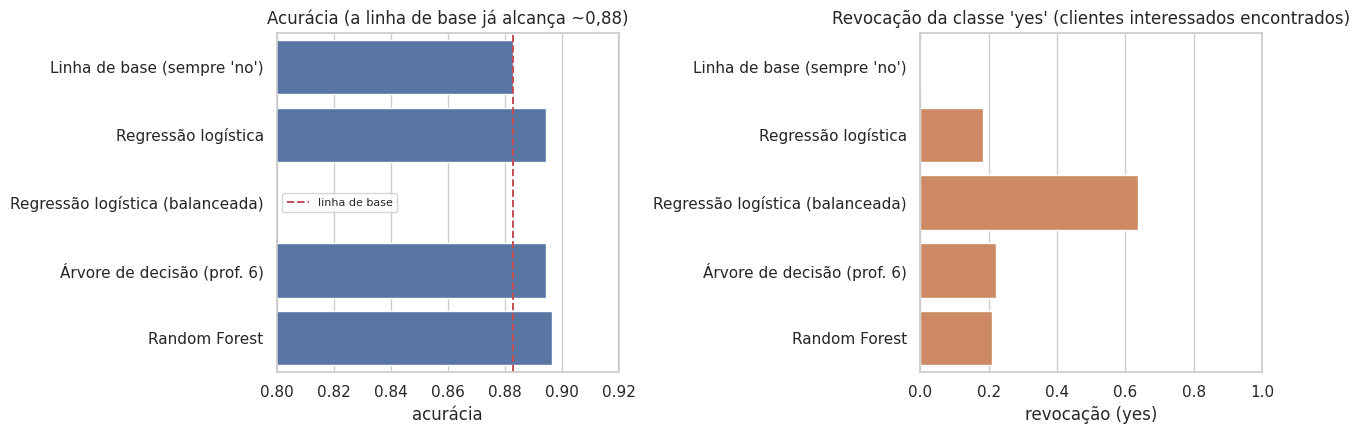

In [49]:
# Leitura gráfica: acurácia sozinha esconde a diferença entre os modelos.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=comparacao_modelos, y="modelo", x="acurácia", color="#4C72B0", ax=axes[0])
axes[0].set(title="Acurácia (a linha de base já alcança ~0,88)", xlim=(0.80, 0.92), ylabel="")
axes[0].axvline(comparacao_modelos.loc[0, "acurácia"], color="#C44E52", linestyle="--",
                linewidth=1.4, label="linha de base")
axes[0].legend(fontsize=8)

sns.barplot(data=comparacao_modelos, y="modelo", x="revocação (yes)", color="#DD8452", ax=axes[1])
axes[1].set(title="Revocação da classe 'yes' (clientes interessados encontrados)",
            xlim=(0, 1), ylabel="")

plt.tight_layout()
plt.show()

In [50]:
# Demonstração do vazamento: o que aconteceria se 'duration' fosse mantida.
X_com_duration = banco_modelo.drop(columns=["y"])   # mantém duration
Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(
    X_com_duration, y_banco, test_size=0.25,
    random_state=RANDOM_STATE, stratify=y_banco,
)

num_d = X_com_duration.select_dtypes(include="number").columns.tolist()
cat_d = [c for c in X_com_duration.columns if c not in num_d]

modelo_com_vazamento = Pipeline(steps=[
    ("preprocessamento", ColumnTransformer([
        ("num", StandardScaler(), num_d),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_d),
    ])),
    ("modelo", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
modelo_com_vazamento.fit(Xtr_d, ytr_d)
y_pred_vaz = modelo_com_vazamento.predict(Xte_d)

demo_vazamento = pd.DataFrame([
    avaliar("SEM 'duration' (usado no trabalho)", y_test_bk, y_pred_log_bk),
    avaliar("COM 'duration' (vazamento)", yte_d, y_pred_vaz),
])
display(demo_vazamento.round(4))

,modelo,acurácia,precisão (yes),revocação (yes),F1 (yes),positivos previstos
0,SEM 'duration' (usado no trabalho),0.8945,0.6826,0.1838,0.2896,356
1,COM 'duration' (vazamento),0.9016,0.6454,0.3525,0.4560,722


**Leitura da comparação:**

- **A acurácia praticamente não distingue os modelos não balanceados.** Regressão logística (0,894), árvore de
  decisão (0,895) e Random Forest (0,897) ficam todos a menos de 1,5 ponto percentual da linha de base (0,883),
  que nunca prevê contratação. Se o grupo olhasse só a acurácia, concluiria que os três são equivalentes — ou,
  pior, escolheria o modelo errado.
- **A revocação da classe `yes` separa claramente os modelos.** Os três encontram uma fração pequena dos clientes
  interessados: entre 18% e 22%. São conservadores e preveem `yes` raramente (a logística padrão indica apenas 356
  contatos, contra 1.322 positivos reais no teste), porque errar na classe rara custa pouco no erro total. A versão
  **balanceada** encontra 63,6% dos interessados, ao custo de muitos falsos positivos e de uma acurácia bem menor
  (0,752) — abaixo, inclusive, da linha de base.
- **Qual escolher depende do custo do erro.** Como discutido em 3.1, o falso negativo (perder uma venda) custa mais
  do que o falso positivo (uma ligação sem retorno). Sob esse critério, **a regressão logística balanceada é a mais
  adequada ao objetivo do negócio**, mesmo tendo a menor acurácia entre os modelos treinados. Essa é a decisão do grupo.
- **A demonstração do vazamento confirma o alerta da seção 3.3.7.** Ao reincluir `duration`, a acurácia sobe pouco
  (0,894 para 0,902), mas a revocação da classe `yes` quase dobra (0,184 para 0,353) e o F1 sobe de 0,29 para 0,46.
  É um ganho ilusório: no momento em que o banco precisa decidir para
  quem ligar, a duração da ligação ainda não existe. Números assim são exatamente o tipo de resultado bom demais
  que deve levantar suspeita de vazamento.

### 3.3.13 Matriz de confusão

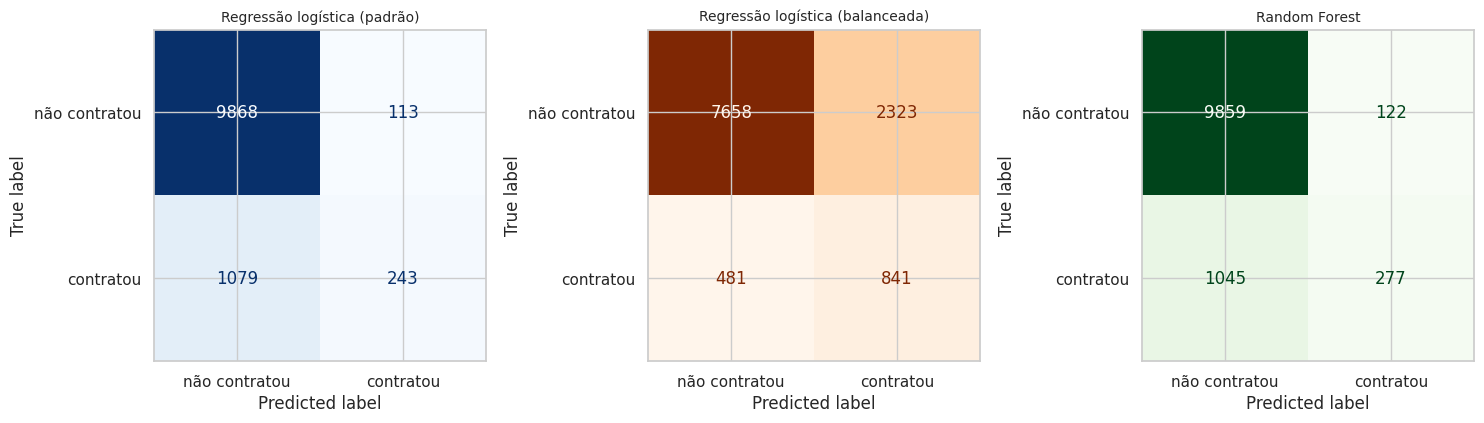

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

for ax, (titulo, previsoes, cor) in zip(axes, [
    ("Regressão logística (padrão)", y_pred_log_bk, "Blues"),
    ("Regressão logística (balanceada)", y_pred_log_bal, "Oranges"),
    ("Random Forest", y_pred_rf_bk, "Greens"),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test_bk, previsoes,
        display_labels=["não contratou", "contratou"],
        cmap=cor, ax=ax, colorbar=False, values_format="d",
    )
    ax.set_title(titulo, fontsize=10)

plt.tight_layout()
plt.show()

In [52]:
# Leitura numérica da matriz do modelo escolhido pelo grupo.
tn, fp, fn, tp = confusion_matrix(y_test_bk, y_pred_log_bal).ravel()

print("MODELO ESCOLHIDO: regressão logística com class_weight='balanced'\n")
print(f"Verdadeiros negativos (não contrataria e não foi previsto): {tn:>6}")
print(f"Falsos positivos      (ligação sem retorno)               : {fp:>6}")
print(f"Falsos negativos      (venda perdida)                     : {fn:>6}")
print(f"Verdadeiros positivos (contratação identificada)           : {tp:>6}")

total_positivos = tp + fn
print(f"\nDos {total_positivos} clientes que contrataram no conjunto de teste, "
      f"o modelo identificou {tp} ({tp / total_positivos * 100:.1f}%).")
print(f"Para isso, indicou {tp + fp} ligações — "
      f"{(tp + fp) / len(y_test_bk) * 100:.1f}% da base de teste.")
print(f"Taxa de acerto entre os indicados: {tp / (tp + fp) * 100:.1f}% "
      f"(contra {y_test_bk.mean() * 100:.1f}% se as ligações fossem aleatórias).")

print("\nRelatório completo:")
print(classification_report(y_test_bk, y_pred_log_bal,
                            target_names=["não contratou", "contratou"], digits=3))

MODELO ESCOLHIDO: regressão logística com class_weight='balanced'

Verdadeiros negativos (não contrataria e não foi previsto):   7658
Falsos positivos      (ligação sem retorno)               :   2323
Falsos negativos      (venda perdida)                     :    481
Verdadeiros positivos (contratação identificada)           :    841

Dos 1322 clientes que contrataram no conjunto de teste, o modelo identificou 841 (63.6%).
Para isso, indicou 3164 ligações — 28.0% da base de teste.
Taxa de acerto entre os indicados: 26.6% (contra 11.7% se as ligações fossem aleatórias).

Relatório completo:
               precision    recall  f1-score   support

não contratou      0.941     0.767     0.845      9981
    contratou      0.266     0.636     0.375      1322

     accuracy                          0.752     11303
    macro avg      0.603     0.702     0.610     11303
 weighted avg      0.862     0.752     0.790     11303



**Interpretação da matriz de confusão (modelo escolhido):**

A leitura por quadrante mostra o que a acurácia esconde. O modelo balanceado indica 3.164 ligações — 28% da base
de teste — e, dentro dessa lista, encontra 841 dos 1.322 clientes que de fato contratariam (63,6%). A taxa de
acerto entre os indicados é de 26,6%, contra 11,7% de uma lista aleatória do mesmo tamanho: **mais que o dobro
da eficiência por ligação**, cortando 72% do esforço da campanha e ainda assim capturando quase dois terços das
contratações.

**Um erro concreto:** os **falsos positivos** são clientes que o modelo mandou ligar e que não contrataram.
Olhando os padrões da análise exploratória, boa parte desse grupo tem características que o modelo associou a
sucesso — por exemplo, `poutcome = success` em campanha anterior ou perfil `retired` — mas que, naquele contato
específico, não converteram. O modelo trabalha com regularidades da população, não com a decisão individual;
ele não tem acesso a nada sobre o momento de vida do cliente, a oferta concorrente que ele recebeu ou o humor
de quem atendeu o telefone. Esse é o limite do que os dados disponíveis permitem prever.

**O erro mais caro** continua sendo o falso negativo: clientes que contratariam e que o modelo descartou. Eles
somem do relatório da campanha, porque a ligação nunca aconteceu e ninguém registra a venda que não foi feita.
Reduzir esse número foi exatamente a razão de escolher a versão balanceada.

## 3.4 Conclusão técnica do grupo

**Síntese dos padrões observados na análise exploratória.**
A base reúne 45.211 contatos telefônicos de uma campanha de depósito a prazo, sem valores nulos e sem duplicatas,
mas com valores desconhecidos codificados como `unknown` em quatro colunas categóricas. A taxa de contratação é de
11,7%, o que caracteriza um problema fortemente desbalanceado. Os grupos com maior taxa de contratação são
`student` e `retired` entre as ocupações, clientes com escolaridade `tertiary`, clientes sem financiamento
imobiliário e, sobretudo, clientes cuja campanha anterior terminou em sucesso (`poutcome = success`). Há também
sazonalidade: os meses de maior volume de ligações não coincidem com os de maior taxa de conversão. Todas essas
são associações observadas na amostra; a base não permite afirmar causas.

**Comparação da acurácia dos modelos.**
A linha de base que responde sempre "não contrata" já atinge cerca de 88% de acurácia. A regressão logística
padrão e o Random Forest ficam ligeiramente acima disso, e a regressão logística balanceada fica abaixo. Isso
mostra que, neste problema, **a acurácia é uma métrica pouco informativa**: ela é dominada pela classe majoritária
e não distingue um modelo útil de um modelo que nunca prevê a classe de interesse. Ao acrescentar precisão,
revocação e F1 da classe `yes`, os modelos passam a se diferenciar de forma clara, e a decisão do grupo mudou:
escolhemos a regressão logística balanceada, que tem a menor acurácia mas encontra a maior parte dos clientes
interessados — o que corresponde ao objetivo declarado em 3.1.

**Leitura básica da matriz de confusão.**
No modelo escolhido, os 841 verdadeiros positivos representam 63,6% dos clientes que contrataram no conjunto de
teste, ao custo de 2.323 falsos positivos (ligações sem retorno). Os falsos negativos, que são as vendas perdidas,
caem para 481. A lista gerada pelo modelo tem taxa de acerto de 26,6%, mais que o dobro dos 11,7% de uma lista
aleatória do mesmo tamanho — esse é o ganho prático da modelagem.

**Limitações do conjunto de dados e da modelagem.**

- Os dados são de **um único banco português entre 2008 e 2010**, período que inclui a crise financeira. O
  comportamento de clientes em relação a aplicações de renda fixa naquele contexto não se transfere
  automaticamente para outro país, outra instituição ou o presente.
- A base descreve **contatos, não clientes**. Um mesmo cliente pode aparecer em mais de uma linha, o que significa
  que as observações não são totalmente independentes — uma premissa implícita na divisão aleatória entre treino
  e teste. Como não há identificador de cliente, não foi possível corrigir isso.
- **Removemos `duration`** por vazamento, e essa era a variável mais associada ao alvo. O modelo resultante é
  honesto, mas necessariamente mais fraco do que os números publicados em análises que mantêm essa coluna.
- Avaliamos **uma única divisão treino/teste**, sem validação cruzada, e **não ajustamos hiperparâmetros**. As
  diferenças pequenas entre modelos estão dentro da margem de variação esperada e não devem ser tratadas como
  definitivas.
- A avaliação **não incorpora custos monetários reais**. Tratamos o falso negativo como mais caro que o falso
  positivo com base em um raciocínio qualitativo; sem os custos efetivos de ligação e a receita média por
  contratação, a escolha do modelo continua sendo uma decisão de critério, não de otimização.
- O modelo **descreve padrões estatísticos observados nesta base**. Ele não comprova nem garante que um cliente
  específico contratará ou deixará de contratar, e não deve ser usado como justificativa isolada para negar
  atendimento a ninguém.

**Melhorias que seriam testadas em uma próxima versão.**

1. **Validação cruzada estratificada** (`StratifiedKFold`) para estimar as métricas com intervalo de variação, em
   vez de um único corte.
2. **Ajuste do limiar de decisão** a partir das probabilidades (`predict_proba`), em vez de aceitar o corte padrão
   de 0,5, escolhendo o ponto da curva precisão-revocação que melhor atende à capacidade diária da equipe.
3. **Métricas independentes de limiar**, como ROC AUC e principalmente PR AUC, mais adequada a bases desbalanceadas.
4. **Busca de hiperparâmetros** com `GridSearchCV` ou `RandomizedSearchCV`, otimizando F1 ou revocação da classe
   `yes` em vez de acurácia.
5. **Tratamento da não linearidade da idade**, discretizando `age` em faixas (`KBinsDiscretizer`) ou aplicando
   termos polinomiais, já que o achado 4 da análise exploratória indica que jovens e aposentados contratam mais —
   um padrão em "U" que a regressão logística não captura sobre a variável bruta.
6. **Outros algoritmos do `scikit-learn`**, como `GradientBoostingClassifier` ou `HistGradientBoostingClassifier`,
   que costumam lidar bem com esse tipo de tabela mista.
7. **Análise dos coeficientes da regressão logística** para explicar quais variáveis mais empurram a previsão em
   cada direção, tornando o modelo defensável para a área de negócio.
8. **Curva de ganho acumulado** ("lift"), que traduz o modelo na linguagem da operação: quantas contratações são
   capturadas ao ligar para os 10%, 20% ou 30% da lista mais bem classificados.

# Parte 2 — Apresentação e demonstração

O grupo deverá demonstrar a implementação escolhida no Exercício 3. A apresentação deve evidenciar compreensão do processo, e não apenas mostrar o notebook pronto.

## Roteiro sugerido

1. **Problema e dados:** tema, fonte, unidade de análise, variável-alvo e classes.
2. **Análise exploratória:** dois ou três achados relevantes e possíveis problemas da base.
3. **Pré-processamento:** o que foi feito e por que foi necessário.
4. **Modelagem:** algoritmos escolhidos e forma de divisão dos dados.
5. **Resultados:** comparação da acurácia e leitura da matriz de confusão.
6. **Decisão:** modelo selecionado, limitações e melhorias futuras.

## Durante a demonstração

- execute ou apresente células essenciais do fluxo;
- explique uma transformação de pré-processamento;
- mostre como as previsões são geradas;
- interprete ao menos um erro da matriz de confusão;
- responda às perguntas do professor sobre decisões do grupo.

> Todos os integrantes podem ser questionados sobre qualquer parte entregue.

# Critérios de avaliação

## Parte 1 — Implementação: 70 pontos

| Critério | Pontos |
|---|---:|
| Carga, compreensão e organização dos dados | 10 |
| Análise exploratória e qualidade das interpretações | 15 |
| Pré-processamento básico dos dados | 15 |
| Treinamento correto e comparação dos modelos | 15 |
| Acurácia, matriz de confusão e interpretação | 10 |
| Conclusão, limitações e organização do notebook | 5 |

## Parte 2 — Apresentação: 30 pontos

| Critério | Pontos |
|---|---:|
| Clareza na contextualização do problema e dos dados | 5 |
| Demonstração do fluxo implementado | 10 |
| Interpretação dos resultados e justificativa das decisões | 10 |
| Participação e domínio do grupo | 5 |

**Total: 100 pontos**

# Checklist final

- [ ] Identificação do grupo preenchida. *(preencher nomes e RMs no topo do notebook e no README)*
- [x] Exercício 2 concluído e interpretado.
- [x] Exercício 3 desenvolvido com um dos quatro temas. *(Economia — Bank Marketing)*
- [x] CSV utilizado está acessível ou sua obtenção está documentada. *(pasta `dados/`, com download automático de reserva)*
- [x] Notebook executado do início ao fim sem erros.
- [x] Resultados e gráficos permanecem visíveis.
- [x] Dois ou mais modelos foram comparados. *(linha de base, regressão logística, logística balanceada, árvore de decisão e Random Forest)*
- [x] Acurácia e matriz de confusão foram interpretadas.
- [x] Conclusão inclui limitações.
- [ ] Grupo está preparado para demonstrar e explicar a implementação.